# Amazon Review Sentiment Analysis — EDA & Preprocessing

## What this notebook does
1. Loads and explores the raw Amazon Fine Food Reviews dataset
2. Creates sentiment labels from numeric scores
3. Cleans and preprocesses text using lemmatization (not stemming)
4. Enriches features with summary weighting, negation preservation, bigrams and trigrams
5. Weights reviews by helpfulness votes
6. Splits data into train / validation / test sets and saves them

## Why lemmatization over stemming
PorterStemmer aggressively truncates words: 'better' → 'better' (ok) but 'easily' → 'easili' (broken).
WordNetLemmatizer uses vocabulary and grammar rules: 'better' → 'good', 'running' → 'run'.
For sentiment analysis, preserving the correct root form matters — 'good' and 'best' carry more
signal than 'good' and 'best' mangled by aggressive truncation.

## Cell 1 — Imports and NLTK Setup

We download four NLTK resources:
- `stopwords` — common words to remove (the, is, at)
- `wordnet` — vocabulary database used by the lemmatizer
- `omw-1.4` — Open Multilingual Wordnet, extends wordnet coverage
- `averaged_perceptron_tagger` — POS tagger used to lemmatize correctly by word type

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import re
import html
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

print('All imports and NLTK resources ready.')

All imports and NLTK resources ready.


[nltk_data] Error loading stopwords: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>
[nltk_data] Error loading wordnet: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>
[nltk_data] Error loading omw-1.4: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>
[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [Errno 8] nodename nor servname provided, or not
[nltk_data]     known>


## Cell 2 — Load Dataset and Exploratory Analysis

The dataset contains 568,454 Amazon food reviews spanning 10+ years.
Each row has: Id, ProductId, UserId, ProfileName, HelpfulnessNumerator,
HelpfulnessDenominator, Score (1-5), Time, Summary, Text.

Key observations we expect to see:
- Heavy class imbalance: ~64% of reviews are 5-star
- Score 3 (neutral) is the smallest class
- Some null values in Summary and ProfileName

Shape: (568454, 10)

Null values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Score distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


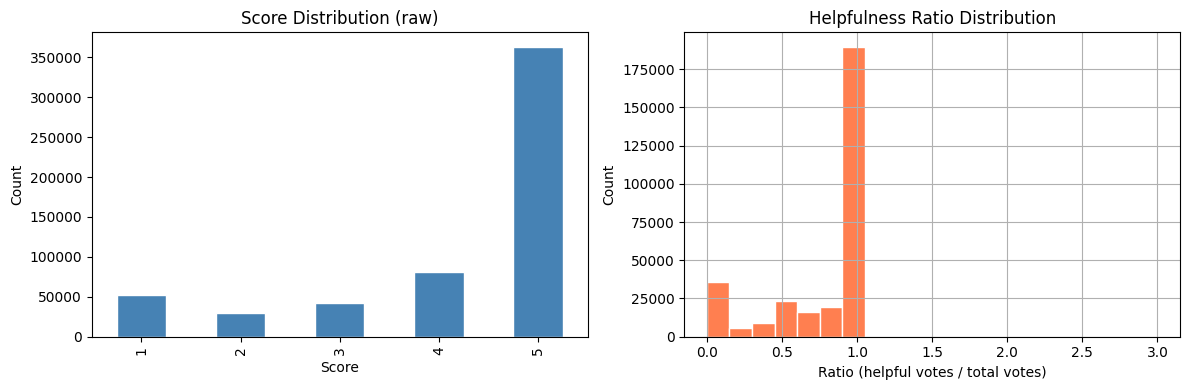

EDA plots saved.


In [2]:
BASE = '/Users/beethoven/BigData/AmazonReview'
df   = pd.read_csv(f'{BASE}/FoodReviews/Reviews.csv')

print(f'Shape: {df.shape}')
print(f'\nNull values:\n{df.isnull().sum()}')
print(f'\nScore distribution:\n{df["Score"].value_counts().sort_index()}')

# Visualize score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Score Distribution (raw)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

# Helpfulness distribution
df_helpful = df[df['HelpfulnessDenominator'] > 0].copy()
df_helpful['helpfulness_ratio'] = (
    df_helpful['HelpfulnessNumerator'] / df_helpful['HelpfulnessDenominator']
)
df_helpful['helpfulness_ratio'].hist(bins=20, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Helpfulness Ratio Distribution')
axes[1].set_xlabel('Ratio (helpful votes / total votes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{BASE}/data/eda_distributions.png', dpi=120)
plt.show()
print('EDA plots saved.')

## Cell 3 — Create Sentiment Labels

We convert numeric scores to 3-class sentiment labels as defined in the project spec:
- Score 1 or 2 → negative
- Score 3       → neutral
- Score 4 or 5  → positive

We also compute a helpfulness weight per review:
- Reviews with many helpful votes are more reliable signal
- Formula: log(1 + helpful_votes) — log dampens extreme values
- Reviews with 0 votes get weight 1.0 (neutral, not penalized)
- This weight is stored and used during model training

Sentiment distribution:
sentiment
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64

Class imbalance ratio positive/neutral: 10.4x

Helpfulness weight stats:
count    568454.000
mean          1.160
std           0.417
min           1.000
25%           1.000
50%           1.000
75%           1.099
max           6.765
Name: helpfulness_weight, dtype: float64


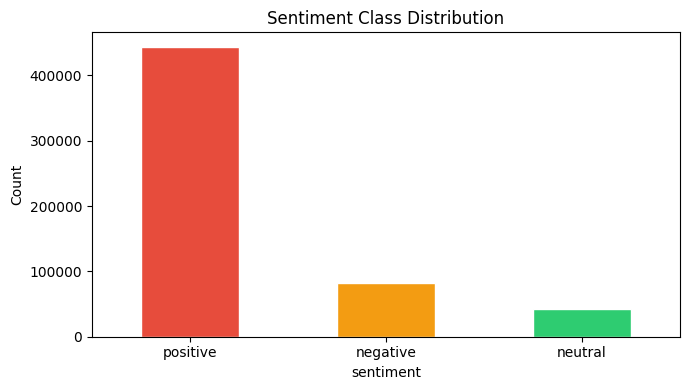

In [3]:
import numpy as np

# Create sentiment label
def label_sentiment(score):
    if score < 3:  return 'negative'
    elif score == 3: return 'neutral'
    else:          return 'positive'

df['sentiment'] = df['Score'].apply(label_sentiment)

print('Sentiment distribution:')
print(df['sentiment'].value_counts())
print(f'\nClass imbalance ratio positive/neutral: '
      f'{df["sentiment"].value_counts()["positive"] / df["sentiment"].value_counts()["neutral"]:.1f}x')

# Compute helpfulness weight
# log(1 + votes) gives diminishing returns — a review with 100 helpful votes
# is not 100x more reliable than one with 1 helpful vote
df['helpfulness_weight'] = np.log1p(df['HelpfulnessNumerator']).clip(lower=1.0)

print(f'\nHelpfulness weight stats:')
print(df['helpfulness_weight'].describe().round(3))

# Visualize class distribution
colors = ['#e74c3c', '#f39c12', '#2ecc71']
df['sentiment'].value_counts().plot(
    kind='bar', color=colors, edgecolor='white', figsize=(7, 4)
)
plt.title('Sentiment Class Distribution')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{BASE}/data/sentiment_distribution.png', dpi=120)
plt.show()

## Cell 4 — Clean Data

Remove noise before preprocessing:
- Drop rows with null Text or Score (cannot be used)
- Drop exact duplicate reviews (same text submitted multiple times)
- Fill null Summary with empty string (some reviews have no summary)

In [4]:
before = len(df)

df = df.dropna(subset=['Text', 'Score'])
df = df.drop_duplicates(subset=['Text'])
df['Summary'] = df['Summary'].fillna('')

after = len(df)
print(f'Rows before cleaning : {before:,}')
print(f'Rows after cleaning  : {after:,}')
print(f'Removed              : {before - after:,}')
print(f'\nSentiment after cleaning:')
print(df['sentiment'].value_counts())

Rows before cleaning : 568,454
Rows after cleaning  : 393,579
Removed              : 174,875

Sentiment after cleaning:
sentiment
positive    306758
negative     57067
neutral      29754
Name: count, dtype: int64


## Cell 5 — Preprocessing Function

### Why each decision matters

**Lemmatizer vs Stemmer:**
PorterStemmer: 'easily' → 'easili', 'better' → 'better', 'studies' → 'studi'
WordNetLemmatizer: 'easily' → 'easily', 'better' → 'good', 'studies' → 'study'
Lemmatizer produces real words that carry more semantic meaning for TF-IDF.

**POS-aware lemmatization:**
The lemmatizer needs to know if a word is a verb, noun, or adjective to lemmatize correctly.
'better' as adjective → 'good'. 'better' without POS → 'better' (unchanged).
We use NLTK POS tagger to get this right.

**Negation preservation:**
Standard stopword lists remove 'not', 'never', 'no'.
This destroys sentiment: 'not good' becomes 'good'.
We explicitly keep negation words.

**Summary repeated 3x:**
The summary is the user's own sentiment headline — their one-line verdict.
Repeating it gives TF-IDF proportionally higher weight to summary terms.

**Bigrams and trigrams:**
Unigrams miss multi-word sentiment: 'not_good', 'highly_recommend', 'waste_money'.
Bigrams capture 2-word patterns. Trigrams capture 3-word phrases.
We test all combinations systematically in the training notebook.

In [5]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

# Negations flip sentiment completely — never remove them
NEGATIONS = {'not', 'no', 'never', 'neither', 'nor', 'barely', 'hardly',
             'scarcely', 'without', 'nowhere', 'nothing', 'nobody'}
stop_words = stop_words - NEGATIONS

def get_wordnet_pos(treebank_tag):
    """Convert Penn Treebank POS tag to WordNet POS tag for lemmatizer."""
    if treebank_tag.startswith('J'): return wordnet.ADJ
    if treebank_tag.startswith('V'): return wordnet.VERB
    if treebank_tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN  # default

def preprocess(row):
    text    = str(row['Text'])
    summary = str(row['Summary'])

    # Summary repeated 3x — gives TF-IDF more weight to the user's headline
    combined = (summary + ' ') * 3 + text

    # Clean HTML artifacts and normalize
    combined = html.unescape(combined)
    combined = re.sub(r'<[^>]+>', ' ', combined)   # remove HTML tags
    combined = combined.lower()
    combined = re.sub(r'[^a-z\s]', ' ', combined)  # keep only letters
    combined = re.sub(r'\s+', ' ', combined).strip()

    # Tokenize
    tokens = combined.split()

    # POS-aware lemmatization + stopword removal
    tagged  = pos_tag(tokens)
    tokens  = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged
        if (word not in stop_words) and len(word) > 1
    ]

    # Bigrams — captures 'not_good', 'highly_recommend', 'waste_money'
    bigrams  = ['_'.join(tokens[i:i+2]) for i in range(len(tokens)-1)]

    # Trigrams — captures 'not_worth_money', 'best_ever_buy'
    trigrams = ['_'.join(tokens[i:i+3]) for i in range(len(tokens)-2)]

    # Return unigrams + bigrams + trigrams combined
    return ' '.join(tokens + bigrams + trigrams)

# Quick test on 3 rows before full run
sample = df.head(3).apply(preprocess, axis=1)
for i, text in enumerate(sample):
    print(f'Sample {i}: {text[:150]}...')
    print()
print('Preprocessing function ready.')

LookupError: 
**********************************************************************
  Resource 'averaged_perceptron_tagger_eng' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('averaged_perceptron_tagger_eng')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'taggers/averaged_perceptron_tagger_eng/'

  Searched in:
    - '/Users/beethoven/nltk_data'
    - '/Users/beethoven/BigData/AmazonReview/.venv/nltk_data'
    - '/Users/beethoven/BigData/AmazonReview/.venv/share/nltk_data'
    - '/Users/beethoven/BigData/AmazonReview/.venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


## Cell 6 — Apply Preprocessing

Applies the preprocessing function to all ~568k reviews.
POS tagging adds computation time vs simple stemming — expect 15-25 minutes.
This is a one-time cost: the results are saved to CSV and reused for all training runs.

In [ ]:
import time

print('Applying preprocessing to all reviews...')
print('This takes 15-25 minutes due to POS tagging. Do not interrupt.')

t0 = time.time()
df['clean_text'] = df.apply(preprocess, axis=1)
elapsed = time.time() - t0

print(f'Done in {elapsed/60:.1f} minutes.')
print(f'\nSample output:')
df[['clean_text', 'sentiment']].head(3)

## Cell 7 — Split and Save

Splits the data into three sets:
- 80% train — used to fit the model
- 10% validation — used to compare models and tune hyperparameters
- 10% test — held out completely, used only for final evaluation and streaming demo

`stratify=df['sentiment']` ensures each split has the same class proportions as the full dataset.
Without stratification, the test set could have very few neutral reviews by chance.

We also save `helpfulness_weight` in each split — it will be used as a sample weight during training.

In [ ]:
SAVE_COLS = [
    'Id', 'ProductId', 'UserId', 'Score', 'Summary', 'Text',
    'clean_text', 'sentiment', 'helpfulness_weight', 'Time'
]

train_val, test = train_test_split(
    df, test_size=0.10, random_state=42, stratify=df['sentiment']
)
train, val = train_test_split(
    train_val, test_size=0.111, random_state=42, stratify=train_val['sentiment']
)

print(f'Train : {len(train):,}')
print(f'Val   : {len(val):,}')
print(f'Test  : {len(test):,}')
print(f'\nTrain sentiment distribution:')
print(train['sentiment'].value_counts())
print(f'\nVal sentiment distribution:')
print(val['sentiment'].value_counts())

train[SAVE_COLS].to_csv(f'{BASE}/data/train.csv', index=False)
val[SAVE_COLS].to_csv(f'{BASE}/data/val.csv',   index=False)
test[SAVE_COLS].to_csv(f'{BASE}/data/test.csv',  index=False)

print('\nFiles saved to /data/')